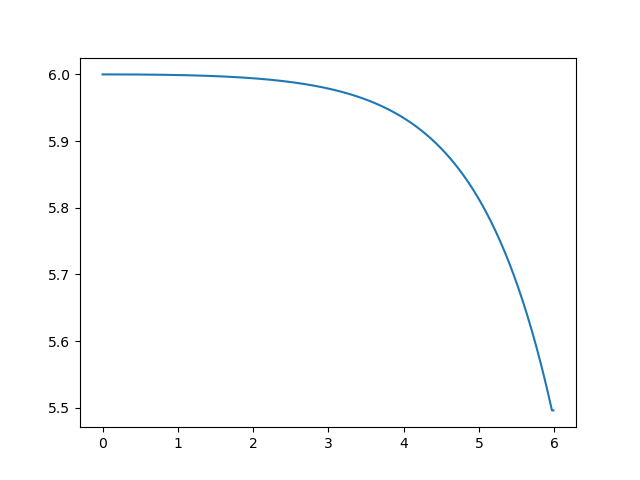

In [241]:
#euler method for cheerios
from scipy.special import k1
import numpy as np
import matplotlib.pyplot as plt
A=1
B=1
ini=[6,0]
R=2.75
m=1
def euler_cheerios(A,B,ini,R,m):
    dt=0.01
    t=np.arange(0,6,dt)
    x=np.zeros(len(t))
    x[0]=ini[0]
    x[1]=ini[0]+ini[1]*dt

    for i in range(len(t)-2):
        v=(x[i+1]-x[i])/dt
        a=B*v/m-A*k1(x[i])/m
        x[i+2]=a*dt**2+2*x[i+1]-x[i]
        if x[i+2]<2*R:
            x[i+2:]=x[i+2]
            break
    plt.close('all')
    plt.plot(t,x)
    
    plt.show
euler_cheerios(A,B,ini,R,m)


C:\Users\Admin\AppData\Local\Temp\ipykernel_4372\903933936.py:41: RuntimeWarning: invalid value encountered in divide
  h_0=(-1/(3*a))*(b+C_k+delta_0/C_k)
C:\Users\Admin\AppData\Local\Temp\ipykernel_4372\903933936.py:55: ComplexWarning: Casting complex values to real discards the imaginary part
  Pot_gravitational[i]=E_tot[i]


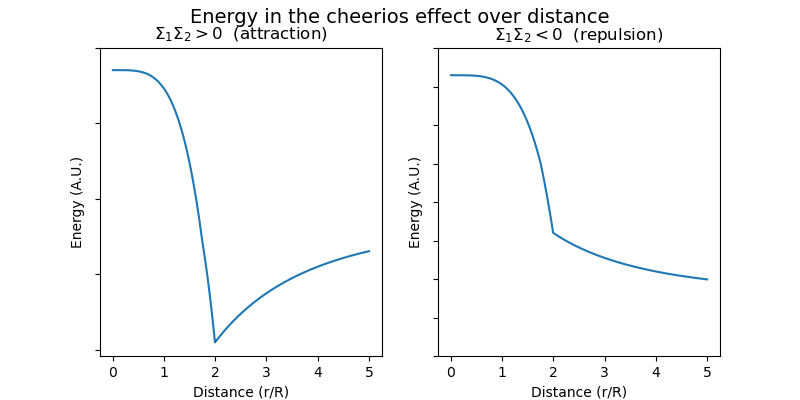

In [242]:
#potential cheerios
from scipy.special import k0
Lc=2.7 #mm
A=10
r_=np.linspace(0,5,1000)
m=0.9
g=9.81
Pot_cheerios=np.zeros(len(r_))
for i in range(150,1000):
    Pot_cheerios[i]=-A*k0(r_[i]/Lc)
Pot_cheerios[:350]=Pot_cheerios[350]

###
r=np.linspace(0,2,400)
R=1
D=0.500000
rho_w=1
rho_s=0.5*rho_w
h=np.sqrt(4*R**2-r**2)
#constants of a*x**3+b*x**2+...=0
a=-2
b=6*R-3*h
c=6*h*R-3*h**2
d=3*R*h**2-h**3-8*R**3*D
#cardano's method
delta_0=b**2-3*a*c
delta_1=2*b**3-9*a*b*c+27*d*a**2
inside_sqrt=delta_1**2-4*delta_0**3+0j
C_inside=(delta_1+np.sqrt(inside_sqrt))/2
#reduce to polar form
angle=np.arctan2(C_inside.imag,C_inside.real)
radius_o=np.sqrt(C_inside.imag**2+C_inside.real**2)
radius=radius_o**(1/3)
angle_new=angle/3
j=1j
C=np.cos(angle_new)*radius+np.sin(angle_new)*radius*j

inside_sqrt_1=-3+0j
k=(-1+np.sqrt(inside_sqrt_1))/2+0j
C_k=C*k**2
h_0=(-1/(3*a))*(b+C_k+delta_0/C_k)

#energy in the balls
hight_1=h_0-R
hight_2=hight_1+h
h_1=h_0+h
E_1 = hight_1 * g * 4 / 3 * np.pi * R**3 * rho_s+np.pi * h_0**2 * (R * h_0 - R**2 - 1 / 4 * h_0**2) * rho_w * g

E_2 = hight_2 * g * 4 / 3 * np.pi * R**3 * rho_s+ np.pi * h_1**2 * (R * h_1 - R**2 - 1 / 4 * h_1**2) * rho_w * g


E_tot=E_1+E_2
Pot_gravitational=np.zeros(len(r_))
for i in range(400):
    Pot_gravitational[i]=E_tot[i]
Pot_gravitational[400:]=Pot_gravitational[399]

Pot=Pot_gravitational+Pot_cheerios
%matplotlib widget
plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(r_,Pot)
ax[0].set_xlabel('Distance (r/R)')
ax[0].set_ylabel('Energy (A.U.)')
ax[0].set_xticks([0,1,2,3,4,5])
ax[0].set_yticks([-22,-18,-14,-10,-6],['','','','',''])
ax[0].set_title(r'$\Sigma _1 \Sigma _2>0$  (attraction)')
Lc=2.7 #mm
A=-10
r_=np.linspace(0,5,1000)
m=0.9
g=9.81
Pot_cheerios=np.zeros(len(r_))
for i in range(150,1000):
    Pot_cheerios[i]=-A*k0(r_[i]/Lc)
Pot_cheerios[:350]=Pot_cheerios[350]
Pot=Pot_gravitational+Pot_cheerios
ax[1].plot(r_,Pot)
ax[1].set_xlabel('Distance (r/R)')
ax[1].set_ylabel('Energy (A.U.)')
ax[1].set_xticks([0,1,2,3,4,5])
ax[1].set_yticks([-22,-18,-14,-10,-6,-2,2,6,10],['','','','','','','','',''])
ax[1].set_title(r'$\Sigma _1 \Sigma _2<0$  (repulsion)')

fig.suptitle('Energy in the cheerios effect over distance', fontsize=14)
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_4372\380344961.py:28: RuntimeWarning: invalid value encountered in divide
  h_0=(-1/(3*a))*(b+C_k+delta_0/C_k)
C:\Users\Admin\anaconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Admin\anaconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


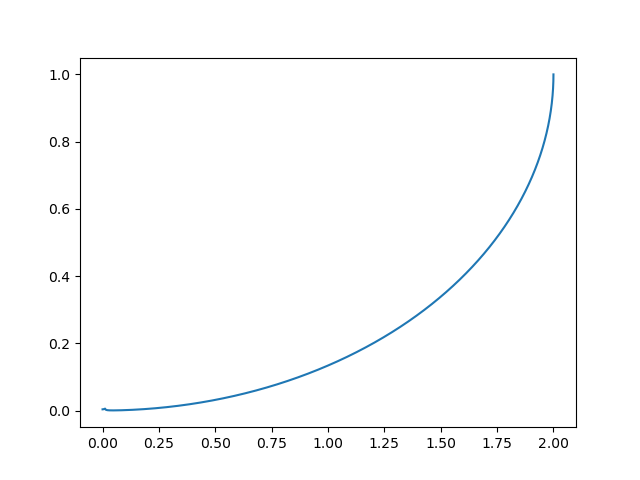

In [243]:
r=np.linspace(0,2,10000)
R=1
D=0.5000001
rho_w=1
rho_s=0.5*rho_w
h=np.sqrt(4*R**2-r**2)
#constants of a*x**3+b*x**2+...=0
a=-2
b=6*R-3*h
c=6*h*R-3*h**2
d=3*R*h**2-h**3-8*R**3*D
#cardano's method
delta_0=b**2-3*a*c
delta_1=2*b**3-9*a*b*c+27*d*a**2
inside_sqrt=delta_1**2-4*delta_0**3+0j
C_inside=(delta_1+np.sqrt(inside_sqrt))/2
#reduce to polar form
angle=np.arctan2(C_inside.imag,C_inside.real)
radius_o=np.sqrt(C_inside.imag**2+C_inside.real**2)
radius=radius_o**(1/3)
angle_new=angle/3
j=1j
C=np.cos(angle_new)*radius+np.sin(angle_new)*radius*j

inside_sqrt_1=-3+0j
k=(-1+np.sqrt(inside_sqrt_1))/2+0j
C_k=C*k**2
h_0=(-1/(3*a))*(b+C_k+delta_0/C_k)
plt.close('all')
plt.plot(r,h_0)
plt.show()



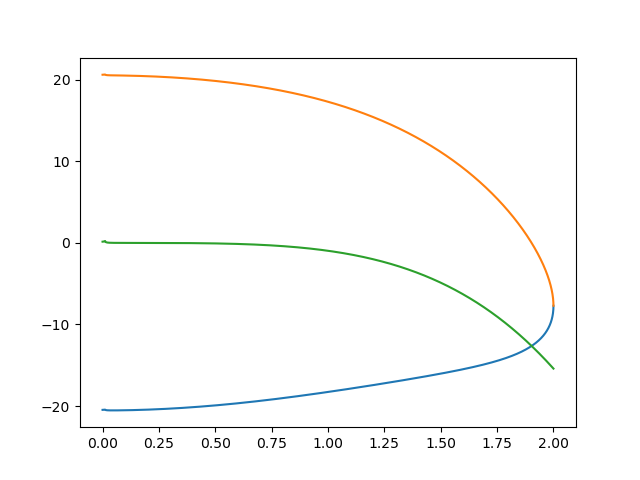

In [244]:
#energy in the balls
hight_1=h_0-R
hight_2=hight_1+h
h_1=h_0+h
E_1=(hight_1*g*4/3*np.pi*R**3*rho_s+np.pi*h_0**2*(R*h_0-R**2-1/4*h_0**2)*rho_w*g)
E_2=(hight_2*g*4/3*np.pi*R**3*rho_s+np.pi*h_1**2*(R*h_1-R**2-1/4*h_1**2)*rho_w*g)

E_tot=E_1+E_2
plt.close('all')
plt.plot(r,E_1)
plt.plot(r,E_2)
plt.plot(r,E_tot)

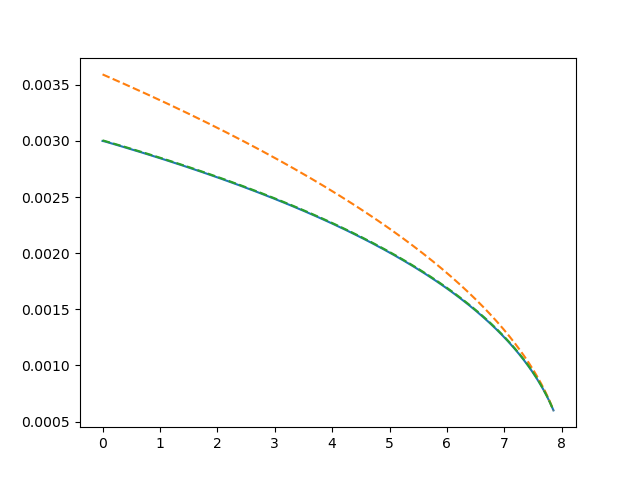

In [245]:
#euler method for cheerios
from scipy.special import k1
import numpy as np
import matplotlib.pyplot as plt
R=3*10**(-4)  #m
Lc=2.7*10**(-3) #m
Sigma=0.6
gamma=0.0728   #N/m
mu=10**(-3)    #Pa s
alpha=0.5
C=1
m=3.59*10**(-8)    #kg
A=-2*np.pi*gamma*R**(6)*Lc**(-5)*Sigma**2
B=-6*np.pi*mu*R*alpha
ini=[10*R,0]


def euler_cheerios_exact(A,B,ini,R,m,Lc,C):
    dt=0.001
    t=np.arange(0,100,dt)
    x=np.zeros(len(t))
    x[0]=ini[0]
    x[1]=ini[0]+ini[1]*dt

    for i in range(len(t)-2):
        v=(x[i+1]-x[i])/dt
        a=B*v/m+A*k1(x[i]/Lc)/(m*C)
        x[i+2]=a*dt**2+2*x[i+1]-x[i]
        if x[i+2]<2*R:
            x=x[:i+3]
            t=t[:i+3]
            break
    return t,x
[t_e_1,x_e_1]=euler_cheerios_exact(A,B,ini,R,m,Lc,C)
plt.close('all')
plt.plot(t_e_1,x_e_1)
t_contact=t_e_1[-1]
l_0=np.sqrt(4*R**2+(2*gamma*R**5*Sigma**2*t_contact)/(3*mu*alpha*Lc**4))
r_a_1=np.sqrt(l_0**2-(2*gamma*R**5*Sigma**2*t_e_1)/(3*mu*alpha*Lc**4))
plt.plot(t_e_1,r_a_1,'--')
initial=2*R
t_initial=t_e_1[-1]
D=-(gamma*R**5*Sigma**2)/(3*mu*alpha*C*Lc**5)
def cheerios_approx(D,initial,t_initial,Lc):
    dt=0.001
    t=np.arange(0,t_initial,dt)
    x=np.zeros(len(t))
    x[-1]=initial
    for i in range(1,len(t)):
        v=D*k1(x[-i]/Lc)
        x[-i-1]=x[-i]-v*dt
    return t,x
[t_ap_1,x_ap_1]=cheerios_approx(D,initial,t_initial,Lc)
plt.plot(t_ap_1,x_ap_1,'--')
plt.show()

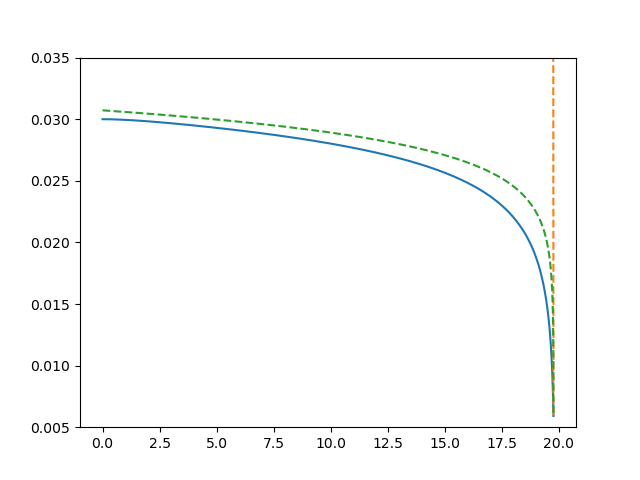

In [246]:
#euler method for cheerios
from scipy.special import k1
import numpy as np
import matplotlib.pyplot as plt
R=3*10**(-3)  #m
Lc=2.7*10**(-3) #m
Sigma=0.6
gamma=0.0728   #N/m
mu=10**(-3)    #Pa s
alpha=0.5
C=1
m=3.59*10**(-5)    #kg
A=-2*np.pi*gamma*R**(6)*Lc**(-5)*Sigma**2
B=-6*np.pi*mu*R*alpha
ini=[10*R,0]



[t_e_2,x_e_2]=euler_cheerios_exact(A,B,ini,R,m,Lc,C)
plt.close('all')
plt.plot(t_e_2,x_e_2)
t_contact=t_e_2[-1]
l_0=np.sqrt(4*R**2+(2*gamma*R**5*Sigma**2*t_contact)/(3*mu*alpha*Lc**4))
r_a_2=np.sqrt(l_0**2-(2*gamma*R**5*Sigma**2*t_e_2)/(3*mu*alpha*Lc**4))
plt.plot(t_e_2,r_a_2,'--')
initial=2*R
t_initial=t_e_2[-1]
D=-(gamma*R**5*Sigma**2)/(3*mu*alpha*C*Lc**5)

[t_ap_2,x_ap_2]=cheerios_approx(D,initial,t_initial,Lc)
plt.plot(t_ap_2,x_ap_2,'--')
plt.ylim(0.005,0.035)
plt.show()

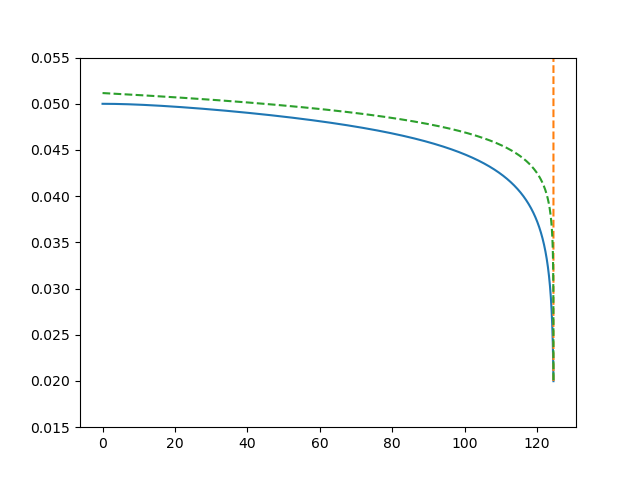

In [247]:
#euler method for cheerios
from scipy.special import k1
import numpy as np
import matplotlib.pyplot as plt
R=10**(-2)  #m
Lc=2.7*10**(-3) #m
Sigma=0.6
gamma=0.0728   #N/m
mu=10**(-3)    #Pa s
alpha=0.5
C=1
m=3.59*10**(-2)/27    #kg
A=-2*np.pi*gamma*R**(6)*Lc**(-5)*Sigma**2
B=-6*np.pi*mu*R*alpha
ini=[5*R,0]

def euler_cheerios_exact(A,B,ini,R,m,Lc,C):
    dt=0.001
    t=np.arange(0,1000,dt)
    x=np.zeros(len(t))
    x[0]=ini[0]
    x[1]=ini[0]+ini[1]*dt

    for i in range(len(t)-2):
        v=(x[i+1]-x[i])/dt
        a=B*v/m+A*k1(x[i]/Lc)/(m*C)
        x[i+2]=a*dt**2+2*x[i+1]-x[i]
        if x[i+2]<2*R:
            x=x[:i+3]
            t=t[:i+3]
            break
    return t,x

[t_e_3,x_e_3]=euler_cheerios_exact(A,B,ini,R,m,Lc,C)
plt.close('all')
plt.plot(t_e_3,x_e_3)
t_contact=t_e_3[-1]
l_0=np.sqrt(4*R**2+(2*gamma*R**5*Sigma**2*t_contact)/(3*mu*alpha*Lc**4))
r_a_3=np.sqrt(l_0**2-(2*gamma*R**5*Sigma**2*t_e_3)/(3*mu*alpha*Lc**4))
plt.plot(t_e_3,r_a_3,'--')
initial=2*R
t_initial=t_e_3[-1]
D=-(gamma*R**5*Sigma**2)/(3*mu*alpha*C*Lc**5)

[t_ap_3,x_ap_3]=cheerios_approx(D,initial,t_initial,Lc)
plt.plot(t_ap_3,x_ap_3,'--')
plt.ylim(0.015,0.055)
plt.show()

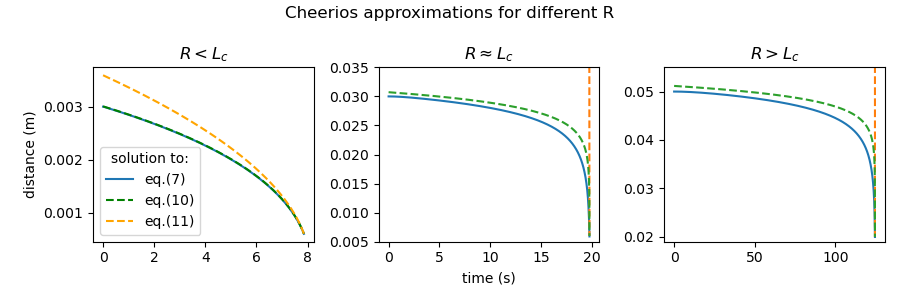

In [248]:
fig,ax=plt.subplots(1,3,figsize=(9,3))
ax1,ax2,ax3=ax[0],ax[1],ax[2]
ax1.plot(t_e_1,x_e_1,label='eq.(7)'),ax1.plot(t_ap_1,x_ap_1,'--',color='green',label='eq.(10)'), ax1.plot(t_e_1,r_a_1,'--',color='orange',label='eq.(11)')
ax1.legend(loc='lower left',title='solution to:')
ax2.plot(t_e_2,x_e_2), ax2.plot(t_e_2,r_a_2,'--'),ax2.plot(t_ap_2,x_ap_2,'--')
ax3.plot(t_e_3,x_e_3), ax3.plot(t_e_3,r_a_3,'--'),ax3.plot(t_ap_3,x_ap_3,'--')
ax2.set_ylim(0.005,0.035)
ax3.set_ylim(0.019,0.055)
ax2.set_xlabel('time (s)')
ax1.set_ylabel('distance (m)')

ax1.set_title(r'$R<L_c$'),ax2.set_title(r'$R\approx L_c$'),ax3.set_title(r'$R>L_c$')

plt.suptitle('Cheerios approximations for different R')
fig.subplots_adjust(bottom=0.22)
plt.tight_layout()

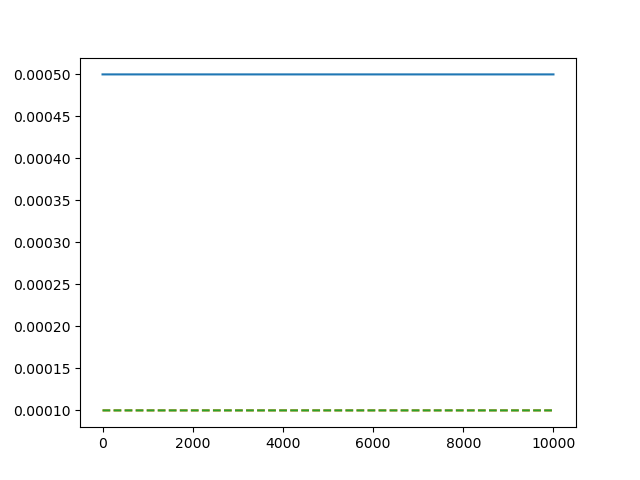

In [249]:
#euler method for cheerios
from scipy.special import k1
import numpy as np
import matplotlib.pyplot as plt
R=5*10**(-5)  #m
Lc=2.7*10**(-1) #m
Sigma=0.6
gamma=0.0728   #N/m
mu=10**(-3)    #Pa s
alpha=0.5
C=1
m=125*3.59*10**(-11)/27    #kg
A=-2*np.pi*gamma*R**(6)*Lc**(-5)*Sigma**2
B=-6*np.pi*mu*R*alpha
ini=[10*R,0]


def euler_cheerios_exact(A,B,ini,R,m,Lc,C):
    dt=0.0001
    t=np.arange(0,10000,dt)
    x=np.zeros(len(t))
    x[0]=ini[0]
    x[1]=ini[0]+ini[1]*dt

    for i in range(len(t)-2):
        v=(x[i+1]-x[i])/dt
        a=B*v/m+A*k1(x[i]/Lc)/(m*C)
        x[i+2]=a*dt**2+2*x[i+1]-x[i]
        if x[i+2]<2*R:
            x=x[:i+3]
            t=t[:i+3]
            break
    return t,x
[t,x]=euler_cheerios_exact(A,B,ini,R,m,Lc,C)
plt.close('all')
plt.plot(t,x)
t_contact=t[-1]
l_0=np.sqrt(4*R**2+(2*gamma*R**5*Sigma**2*t_contact)/(3*mu*alpha*Lc**4))
r=np.sqrt(l_0**2-(2*gamma*R**5*Sigma**2*t)/(3*mu*alpha*Lc**4))
plt.plot(t,r,'--')
initial=2*R
t_initial=t[-1]
D=-(gamma*R**5*Sigma**2)/(3*mu*alpha*C*Lc**5)
def cheerios_approx(D,initial,t_initial,Lc):
    dt=0.001
    t=np.arange(0,t_initial,dt)
    x=np.zeros(len(t))
    x[-1]=initial
    for i in range(1,len(t)):
        v=D*k1(x[-i]/Lc)
        x[-i-1]=x[-i]-v*dt
    return t,x
[t,x]=cheerios_approx(D,initial,t_initial,Lc)
plt.plot(t,x,'--')
plt.show()